# Google Local Data (2021) - Exploratory Analysis

Tasks 1-3: NYC Restaurant Corpus - Data Quality Audit - Temporal Coverage

**File loading strategy:** `meta-New_York.json.gz` (272,189 NY state businesses) is loaded
in full and filtered in memory. `review-New_York_10.json.gz` (18,661,975 reviews, 10-core)
is streamed in 50,000-row chunks filtered to the NYC restaurant `gmap_id` set from Task 1.
A single streaming pass through the review file feeds both Task 2 and Task 3.

| # | Task | Phase | Priority |
|---|---|---|---|
| 1 | NYC Restaurant Corpus Definition | Foundation | P0 |
| 2 | Data Quality Audit | Foundation | P0 |
| 3 | Temporal Coverage & TLC Alignment | Foundation | P0 |

In [1]:
from pathlib import Path
import gzip
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

RAW  = Path('../data/raw/googlelocal')
PROC = Path('../data/processed')
PROC.mkdir(parents=True, exist_ok=True)

REVIEW_FILE = RAW / 'review-New_York_10.json.gz'
META_FILE   = RAW / 'meta-New_York.json.gz'

CHUNK = 50_000

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Task 1 - NYC Restaurant Corpus Definition

Filter `meta-New_York.json.gz` to businesses physically in NYC with at least one food/restaurant
category tag. This corpus drives all downstream filtering: no review data is loaded without
first intersecting against the resulting `gmap_id` set.

**Geographic filter:** Bounding box - latitude [40.45, 40.92], longitude [-74.26, -73.70].
Covers all five boroughs. The `state` field in metadata is business hours status
(e.g. `"Closes soon"`), NOT a US state abbreviation - coordinates are the only reliable
geographic signal.

**Category filter:** Any tag containing `"restaurant"` (case-insensitive) covers all
cuisine-specific variants. An explicit seed set covers non-`restaurant`-named food venues.
Top-30 tags explored first to calibrate the seed before applying the filter.

In [2]:
# NYC bounding box covering all five boroughs
LAT_MIN, LAT_MAX =  40.45,  40.92
LON_MIN, LON_MAX = -74.26, -73.70

print('Loading NY state metadata ...')
meta_chunks = []
with gzip.open(META_FILE, 'rb') as f:
    for chunk in pd.read_json(f, lines=True, chunksize=CHUNK):
        meta_chunks.append(chunk)
meta_all = pd.concat(meta_chunks, ignore_index=True)
print(f'Total NY state businesses:     {len(meta_all):,}')

# Bounding box filter
in_bbox = (
    meta_all['latitude'].between(LAT_MIN, LAT_MAX) &
    meta_all['longitude'].between(LON_MIN, LON_MAX)
)
meta_bbox = meta_all[in_bbox].copy().reset_index(drop=True)
print(f'Within NYC bounding box:       {len(meta_bbox):,}')
del meta_all

Loading NY state metadata ...
Total NY state businesses:     272,189
Within NYC bounding box:       116,122


In [3]:
# Explode category lists to find top tags among bbox-filtered businesses.
# Review this output to confirm the food seed set in the next cell is complete.
cat_counts: dict[str, int] = {}
for cats in meta_bbox['category'].dropna():
    if isinstance(cats, list):
        for c in cats:
            cat_counts[c] = cat_counts.get(c, 0) + 1

cat_series = pd.Series(cat_counts, name='count').sort_values(ascending=False)
print(f'Distinct category tags in NYC bbox businesses: {len(cat_series):,}')
print()
print('Top-30 category tags (review before adjusting food seed in next cell):')
display(cat_series.head(30).to_frame())

Distinct category tags in NYC bbox businesses: 3,269

Top-30 category tags (review before adjusting food seed in next cell):


,count
Restaurant,8799
Bar,4234
Delivery Restaurant,3618
Coffee shop,3091
Fast food restaurant,2814
Cafe,2766
Beauty salon,2623
Grocery store,2552
Bakery,2503
Deli,2399


In [4]:
# Food seed: substring 'restaurant' captures all cuisine-specific variants
# (e.g. 'Italian restaurant', 'Chinese restaurant', 'Pizza restaurant', etc.).
# FOOD_EXPLICIT covers common food venues whose name does not contain 'restaurant'.
# Adjust after reviewing the top-30 output above.
FOOD_EXPLICIT = {
    'food', 'cafe', 'coffee shop', 'bar', 'pub', 'brewery',
    'bakery', 'donut shop', 'ice cream shop', 'sandwich shop',
    'bagel shop', 'juice bar', 'wine bar', 'cocktail bar',
    'diner', 'bistro', 'brasserie', 'food court', 'food truck',
    'meal delivery', 'meal takeaway', 'catering food and drink supplier',
}

def is_food_venue(cats) -> bool:
    if not isinstance(cats, list):
        return False
    for c in cats:
        c_lo = c.lower()
        if 'restaurant' in c_lo or c_lo in FOOD_EXPLICIT:
            return True
    return False

food_mask = meta_bbox['category'].map(is_food_venue)
nyc_meta  = meta_bbox[food_mask].copy().reset_index(drop=True)
print(f'After food category filter:    {len(nyc_meta):,}')

# Borough approximation from coordinates (approximate - no shapefile at this stage)
lat = nyc_meta['latitude']
lon = nyc_meta['longitude']
borough = pd.Series('Queens', index=nyc_meta.index, dtype=object)
borough[lon < -74.04] = 'Staten Island'
borough[(lat > 40.796) & (lon < -73.765)] = 'Bronx'
borough[(lon < -73.875) & (lat < 40.745)] = 'Brooklyn'
borough[(lon > -73.925) & (lat > 40.695)] = 'Manhattan'
nyc_meta['borough'] = borough.values

# Decision gate
if len(nyc_meta) < 5_000:
    print('GATE FAILED: fewer than 5,000 NYC restaurants - widen the food filter')
else:
    print(f'Gate passed: {len(nyc_meta):,} NYC restaurants (threshold: 5,000)')

After food category filter:    32,364
Gate passed: 32,364 NYC restaurants (threshold: 5,000)


In [5]:
borough_counts = nyc_meta['borough'].value_counts()

summary_t1 = pd.DataFrame({
    'metric': [
        'Total NYC restaurants',
        'With price tier',
        'Null price tier',
        'Null avg_rating',
        'Null coordinates',
    ],
    'count': [
        len(nyc_meta),
        nyc_meta['price'].notna().sum(),
        nyc_meta['price'].isna().sum(),
        nyc_meta['avg_rating'].isna().sum(),
        (nyc_meta['latitude'].isna() | nyc_meta['longitude'].isna()).sum(),
    ],
})
summary_t1['share_%'] = (summary_t1['count'] / len(nyc_meta) * 100).round(1)
display(summary_t1.set_index('metric'))

print('\nPrice tier distribution:')
price_dist = (
    nyc_meta['price']
    .fillna('null')
    .value_counts()
    .reindex(['$', '$$', '$$$', '$$$$', 'null'], fill_value=0)
)
display(price_dist.rename('count').to_frame())

,count,share_%
metric,,
Total NYC restaurants,32364,100.0
With price tier,21494,66.4
Null price tier,10870,33.6
Null avg_rating,0,0.0
Null coordinates,0,0.0



Price tier distribution:


,count
price,
$,9696
$$,10335
$$$,1069
$$$$,227
null,10870


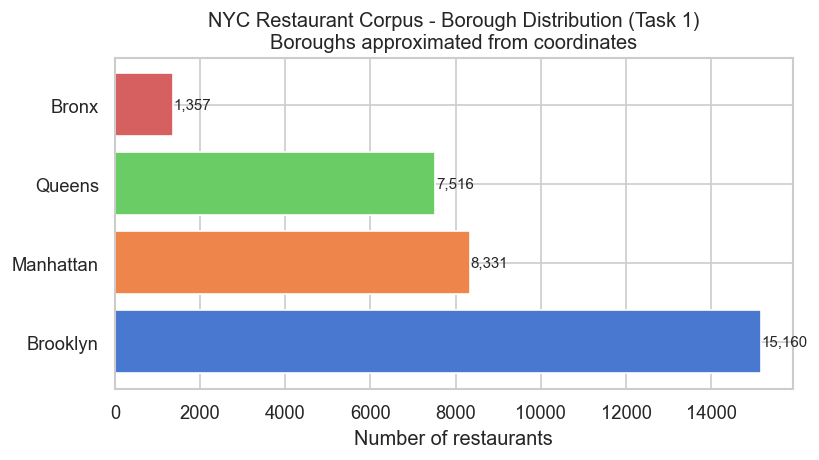

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
pal  = sns.color_palette('muted', n_colors=len(borough_counts))
bars = ax.barh(borough_counts.index, borough_counts.values, color=pal)
for bar, val in zip(bars, borough_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Number of restaurants')
ax.set_title(
    'NYC Restaurant Corpus - Borough Distribution (Task 1)\n'
    'Boroughs approximated from coordinates'
)
plt.tight_layout()
plt.show()

In [7]:
NYC_GMAP_IDS: set = set(nyc_meta['gmap_id'])
with open(PROC / 'nyc_restaurant_gmap_ids.pkl', 'wb') as f:
    pickle.dump(NYC_GMAP_IDS, f)
print(f'Saved {len(NYC_GMAP_IDS):,} gmap_ids -> {PROC / "nyc_restaurant_gmap_ids.pkl"}')

Saved 32,283 gmap_ids -> ../data/processed/nyc_restaurant_gmap_ids.pkl


**Key Finding - NYC Restaurant Corpus**

_(Fill in after execution: total count, borough breakdown, price tier coverage, gate status.)_

## Review Data Collection (Tasks 2 and 3)

Single streaming pass through `review-New_York_10.json.gz`, filtered to NYC restaurant
`gmap_id`s. All data needed for Tasks 2 and 3 is collected here to avoid reading the
18.6M-row file twice. Expect several minutes on first run.

In [9]:
print('Streaming review file ...')

CHUNK_REV = 500_000  # large chunks reduce loop/concat overhead

null_sums = None
total_rows = 0
keep_chunks = []

with gzip.open(REVIEW_FILE, 'rb') as f:
    for chunk in pd.read_json(f, lines=True, chunksize=CHUNK_REV):
        matched = chunk[chunk['gmap_id'].isin(NYC_GMAP_IDS)]
        if matched.empty:
            continue

        chunk_nulls = matched.isnull().sum()
        null_sums = chunk_nulls if null_sums is None else null_sums.add(chunk_nulls, fill_value=0)
        total_rows += len(matched)

        keep_chunks.append(matched[['user_id', 'gmap_id', 'time']].copy())

reviews = pd.concat(keep_chunks, ignore_index=True)
del keep_chunks

null_rates_rev = (null_sums / total_rows * 100).round(1)
dates_dt = pd.to_datetime(reviews['time'], unit='ms', errors='coerce')
user_ids = reviews['user_id']
dup_keys = reviews

print(f'NYC restaurant reviews: {total_rows:,}')
print(f'Unique users: {user_ids.nunique():,}')
print(f'Unique restaurants: {reviews["gmap_id"].nunique():,}')

Streaming review file ...
NYC restaurant reviews: 4,986,344
Unique users: 405,662
Unique restaurants: 27,539


## Task 2 - Data Quality Audit

Null rates, structural issues, and review integrity across both files.
All review analyses are filtered to the NYC restaurant corpus (Task 1 `gmap_id`s).

### 2a - Null Rate Heatmap

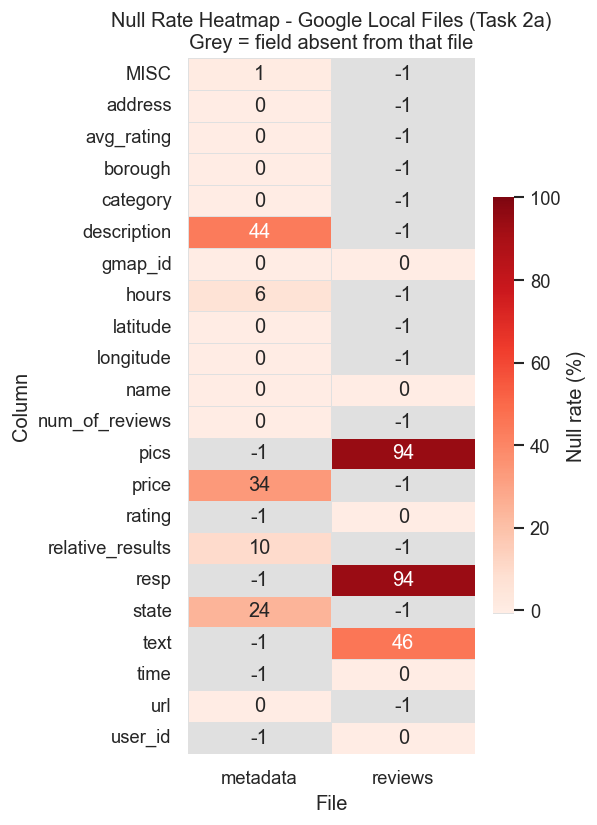

In [ ]:
# Metadata null rates - NYC restaurant subset only
null_rates_meta = (nyc_meta.isnull().sum() / len(nyc_meta) * 100).round(1)

# Combine into a single table (rows = fields, cols = files)
null_df = pd.DataFrame({
    'metadata': null_rates_meta,
    'reviews':  null_rates_rev,
})
null_df = null_df.dropna(how='all').fillna(-1)

cmap_base = plt.cm.Reds
colors_list = [(0.88, 0.88, 0.88, 1.0)]  # grey sentinel for absent field
colors_list += [cmap_base(v) for v in np.linspace(0.05, 0.95, 255)]
cmap = mcolors.ListedColormap(colors_list)

fig, ax = plt.subplots(figsize=(5, max(5, len(null_df) * 0.32)))
sns.heatmap(
    null_df,
    ax=ax,
    cmap=cmap,
    vmin=-1, vmax=100,
    annot=True, fmt='.0f',
    linewidths=0.4, linecolor='#e0e0e0',
    cbar_kws={'label': 'Null rate (%)', 'shrink': 0.6},
)
ax.set_title(
    'Null Rate Heatmap - Google Local Files (Task 2a)\n'
    'Grey = field absent from that file'
)
ax.set_xlabel('File')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

### 2b - `MISC` Key Frequency (NYC Restaurants)

In [ ]:
misc_key_counts: dict[str, int] = {}
for misc_val in nyc_meta['MISC'].dropna():
    if isinstance(misc_val, dict):
        for k in misc_val:
            misc_key_counts[k] = misc_key_counts.get(k, 0) + 1

misc_freq = pd.Series(misc_key_counts, name='count').sort_values(ascending=False)
misc_freq_pct = (misc_freq / len(nyc_meta) * 100).round(1).rename('coverage_%')
misc_table = pd.concat([misc_freq, misc_freq_pct], axis=1)

print(f'Distinct MISC keys among NYC restaurants: {len(misc_table)}')
print()
display(misc_table.head(25))

Distinct MISC keys among NYC restaurants: 14



,count,coverage_%
Service options,31158,96.3
Offerings,25322,78.2
Amenities,21750,67.2
Atmosphere,21544,66.6
Dining options,18699,57.8
Popular for,18546,57.3
Accessibility,17885,55.3
Crowd,16255,50.2
Payments,16211,50.1
Highlights,12989,40.1


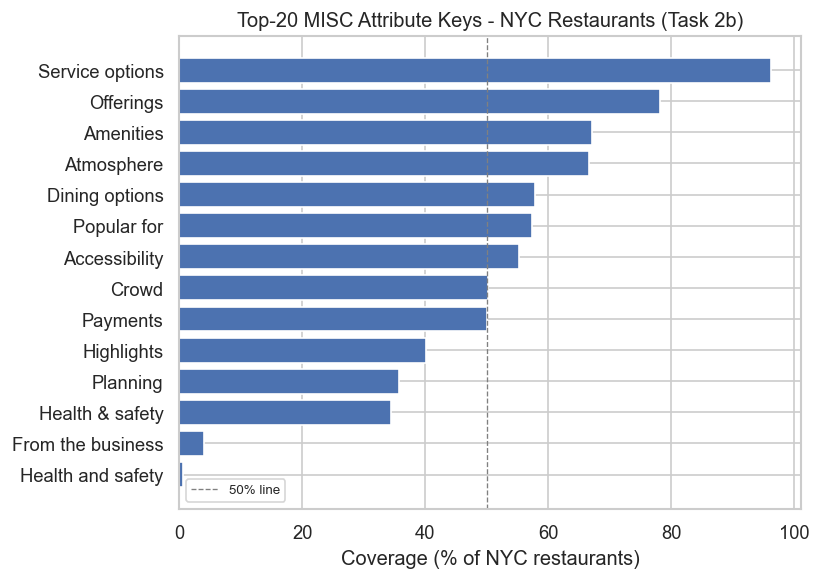

In [12]:
top_misc = misc_freq_pct.head(20)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_misc.index[::-1], top_misc.values[::-1], color='#4c72b0')
ax.set_xlabel('Coverage (% of NYC restaurants)')
ax.set_title('Top-20 MISC Attribute Keys - NYC Restaurants (Task 2b)')
ax.axvline(50, color='grey', linewidth=0.8, linestyle='--', label='50% line')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2c - Review Integrity Checks

In [13]:
n_dup = dup_keys.duplicated().sum()
parse_fail = dates_dt.isna().sum()
too_early = (dates_dt < pd.Timestamp('2000-01-01')).sum()
too_late = (dates_dt > pd.Timestamp('2021-10-01')).sum()
date_min = dates_dt.dropna().min()
date_max = dates_dt.dropna().max()

print(f'Total NYC restaurant reviews: {total_rows:>10,}')
print(f'Duplicate (user_id, gmap_id, time) triples: {n_dup:>10,}  ({n_dup / total_rows * 100:.2f}%)')
print()
print(f'Timestamp parse failures: {parse_fail:>10,}')
print(f'Timestamps before 2000-01-01: {too_early:>10,}')
print(f'Timestamps after 2021-10-01 (data cutoff): {too_late:>10,}')
print(f'Date range: {date_min:%Y-%m-%d} to {date_max:%Y-%m-%d}')
print()
if n_dup > 0:
    print('Decision: keep the most-recent record per (user_id, gmap_id) pair '
          'in Epic 2 to avoid double-counting interactions.')
else:
    print('No duplicate (user_id, gmap_id, time) triples - no deduplication needed.')

Total NYC restaurant reviews:  4,986,344
Duplicate (user_id, gmap_id, time) triples:     61,715  (1.24%)

Timestamp parse failures:          0
Timestamps before 2000-01-01:        236
Timestamps after 2021-10-01 (data cutoff):          0
Date range: 1990-12-31 to 2021-09-06

Decision: keep the most-recent record per (user_id, gmap_id) pair in Epic 2 to avoid double-counting interactions.


**Key Finding - Data Quality Audit**

_(Fill in after execution: null-rate highlights, MISC key coverage, price tier coverage, duplicate review decision, timestamp range.)_

## Task 3 - Temporal Coverage & TLC Alignment

Date range of NYC restaurant reviews and assessment of the temporal gap with TLC trip data
(Jan 2025 - Feb 2026). Google Local data cuts off Sep 2021, a gap of roughly 3.5 years to
the TLC window. This gap must be documented in the final report. The synthetic identity layer
absorbs it by construction.

In [14]:
# Use only valid, in-range timestamps
valid_mask  = dates_dt.notna() & (dates_dt >= pd.Timestamp('2000-01-01'))
dates_ok    = dates_dt[valid_mask].reset_index(drop=True)
user_ids_ok = user_ids[valid_mask].reset_index(drop=True)

year_counts = dates_ok.dt.year.value_counts().sort_index()
year_pct    = (year_counts / len(dates_ok) * 100).round(2)
year_table  = pd.DataFrame({'reviews': year_counts, 'share_%': year_pct})
display(year_table)

earlieset  = dates_ok.min()
latest     = dates_ok.max()
peak_year  = year_counts.idxmax()

print(f'\nEarliest review: {earlieset:%Y-%m-%d}')
print(f'Latest review:   {latest:%Y-%m-%d}')
print(f'Peak year:       {peak_year}  ({year_counts[peak_year]:,} reviews, '
      f'{year_pct[peak_year]:.1f}%)')

,reviews,share_%
time,,
2000,1,0.00
2001,1,0.00
2002,89,0.00
2003,108,0.00
2004,163,0.00
2005,724,0.01
2006,918,0.02
2007,814,0.02
2008,1052,0.02



Earliest review: 2000-01-07
Latest review:   2021-09-06
Peak year:       2019  (1,597,365 reviews, 32.0%)


In [15]:
# Decision gate
pct_2018_plus = year_pct[year_pct.index >= 2018].sum()
print(f'Reviews from 2018 or later: {pct_2018_plus:.1f}%')
if pct_2018_plus < 50:
    print('GATE: <50% of reviews from 2018+ - flag data recency risk in final report')
else:
    print('Gate passed: >=50% of reviews from 2018+')

# TLC temporal gap
TLC_START = pd.Timestamp('2025-01-01')
TLC_END   = pd.Timestamp('2026-02-28')
post_2025 = (dates_ok >= TLC_START).sum()

print(f'\nTLC trip data window: {TLC_START:%Y-%m-%d} to {TLC_END:%Y-%m-%d}')
print(f'Google reviews overlapping TLC window (>= Jan 2025): {post_2025:,}')
if post_2025 == 0:
    print('TEMPORAL GAP: No Google reviews in the TLC window.')
    print('Google data cuts off Sep 2021; TLC window starts Jan 2025 (~3.5-year gap).')
    print('Document in final report. Synthetic identity layer absorbs this by construction.')
else:
    print(f'Note: {post_2025:,} reviews fall within the TLC window.')

# Unique users with at least one NYC review from 2018 onward
mask_2018       = dates_ok.dt.year >= 2018
users_post2018  = user_ids_ok[mask_2018].nunique()
print(f'\nUnique users with >=1 NYC restaurant review from 2018 onward: {users_post2018:,}')

Reviews from 2018 or later: 77.2%
Gate passed: >=50% of reviews from 2018+

TLC trip data window: 2025-01-01 to 2026-02-28
Google reviews overlapping TLC window (>= Jan 2025): 0
TEMPORAL GAP: No Google reviews in the TLC window.
Google data cuts off Sep 2021; TLC window starts Jan 2025 (~3.5-year gap).
Document in final report. Synthetic identity layer absorbs this by construction.

Unique users with >=1 NYC restaurant review from 2018 onward: 375,939


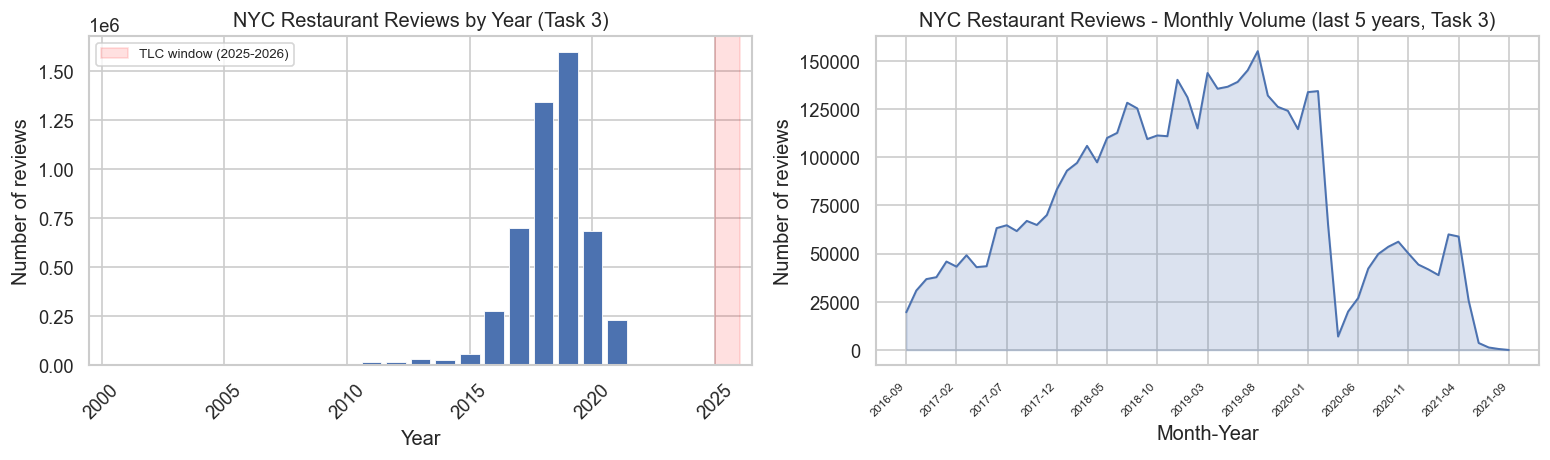

In [16]:
TLC_START = pd.Timestamp('2025-01-01')
TLC_END   = pd.Timestamp('2026-02-28')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot A: review volume by year (numeric x-axis to support axvspan)
years = year_counts.index.values
ax = axes[0]
ax.bar(years, year_counts.values, color='#4c72b0', edgecolor='white',
       linewidth=0.5, width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Number of reviews')
ax.set_title('NYC Restaurant Reviews by Year (Task 3)')
ax.tick_params(axis='x', rotation=45)
# Extend x-axis to include TLC window and shade the gap visually
ax.set_xlim(years.min() - 0.5, TLC_END.year + 0.5)
ax.axvspan(
    TLC_START.year, TLC_END.year,
    alpha=0.12, color='red',
    label=f'TLC window ({TLC_START.year}-{TLC_END.year})',
)
ax.legend(fontsize=8)

# Plot B: monthly volume (last 5 years)
ax2 = axes[1]
cutoff       = dates_ok.max() - pd.DateOffset(years=5)
recent_dates = dates_ok[dates_ok >= cutoff]
monthly      = recent_dates.dt.to_period('M').value_counts().sort_index()
tick_step    = max(1, len(monthly) // 12)
ax2.plot(range(len(monthly)), monthly.values, color='#4c72b0', linewidth=1.2)
ax2.fill_between(range(len(monthly)), monthly.values, alpha=0.2, color='#4c72b0')
ax2.set_xticks(range(0, len(monthly), tick_step))
ax2.set_xticklabels(
    [str(p) for p in monthly.index[::tick_step]],
    rotation=45, ha='right', fontsize=7,
)
ax2.set_xlabel('Month-Year')
ax2.set_ylabel('Number of reviews')
ax2.set_title('NYC Restaurant Reviews - Monthly Volume (last 5 years, Task 3)')

plt.tight_layout()
plt.show()

**Key Finding - Temporal Coverage & TLC Alignment**

_(Fill in after execution: date range, peak year, % from 2018+, unique recent users count, temporal gap assessment.)_